In [124]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# Importing Model Data
check=False
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'

# dx = 1 km; Np = 1M; Nt = 5 min
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_5min.nc') #***
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_5min_1e6.nc') #***
res='1km';t_res='5min'
Np_str='1e6'

# # dx = 1km; Np = 50M
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_50M.nc') #***
# res='1km'; t_res='1min'; Np_str='50e6'

# # dx = 1km; Np = 50M; Nz = 95
# #Importing Model Data
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_1km_1min_95nz.nc') #***
# parcel=xr.open_dataset(dir2+'cm1out_pdata_1km_1min_95nz.nc') #***
# res='1km'; t_res='1min_95nz'; Np_str='50e6'

In [125]:
#LOAD VARIABLES
################################################################################
def LoadData(data_t,approximation):
    #LOADING TERMS
    th=data_t['th'].data
    rv=data_t['qv'].data #called qv in cm1, but is really rv ("mixing ratio")
    rl=data_t['qc'].data+data_t['qr'].data

    #MAKING PERTURBATION TERMS
    th_mean = np.mean(th, axis=(1, 2), keepdims=True)   # shape (z, 1, 1)
    rv_mean = np.mean(rv, axis=(1, 2), keepdims=True)
    rl_mean = np.mean(rl, axis=(1, 2), keepdims=True)
    th_prime = th - th_mean
    rv_prime = rv - rv_mean
    rl_prime = rl - rl_mean

    #CALCULATING THETA_V_BAR
    Rd=287.04; Rv=461.5; eps=Rd/Rv #located in cm1/src/constants.F 
    if approximation==True:
        a=((1/eps) - 1) #~0.6077
        th_v = th*(1+(a*rv)-rl)
        th_v_mean = np.mean(th_v, axis=(1, 2), keepdims=True)
        
    elif approximation==False:
        N=th*(1+(rv/eps)) #numerator
        D=(1+rv+rl) #denominator
        th_v = N/D
        th_v_mean = np.mean(th_v, axis=(1, 2), keepdims=True)
    
    return th,th_prime, rv,rv_prime, rl,rl_prime, th_v_mean

In [126]:
def BuoyancyDecompTerms(data_t, approximation):
    #GETTING DATA
    [th,th_prime, rv,rv_prime, rl,rl_prime, th_v_mean] = LoadData(data_t,approximation)

    #CALCULATING VARIABLES
    Rd=287.04; Rv=461.5; eps=Rd/Rv #located in cm1/src/constants.F 
    if approximation==True:
        a=((1/eps) - 1) #~0.6077
        D=th_v_mean

        #MAKING INDIVIDUAL BUOYANCY TERMS (3 TOTAL)
        N=(1+(a*rv)-rl)
        th_term = N/D
        N=(a*th)
        rv_term = N/D
        N=-th
        rl_term = N/D

        #also need to multiply by gravity constant g
        g=9.81 #located in cm1/src/constants.F 
        th_term*=g; rv_term*=g; rl_term*=g

        #also multiply by prime terms with each term
        th_term*=th_prime
        rv_term*=rv_prime
        rl_term*=rl_prime

    elif approximation==False:
        A=(1+(rv/eps))/(1+rv+rl)
        D=th_v_mean

        #SOME TERM CONSOLIDATIONS
        B1=(1-eps+rl)
        B2=(eps+rv)
        B3=eps*((1+rv+rl)**2)

        #MAKING INDIVIDUAL BUOYANCY TERMS (3 TOTAL)
        N=A
        th_term = N/D
        N=th*B1/B3
        rv_term = N/D
        N=th*B2/B3
        rl_term = N/D

        #also need to multiply by gravity constant g
        g=9.81 #located in cm1/src/constants.F 
        th_term*=g; rv_term*=g; rl_term*=g

        #also multiply by prime terms with each term
        th_term*=th_prime
        rv_term*=rv_prime
        rl_term*=rl_prime
        

    VARS={
        'th_term': th_term,
        'rv_term': rv_term,
        'rl_term': rl_term
         }
    return VARS

In [127]:
def GetOutputName(approximation):
    dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    # dir2='/mnt/lustre/koa/scratch/air673/'
    if approximation==True:
        out_file = dir2 + 'Variable_Calculation/' + f'Buoyancy_Decomp_{res}_{t_res}.h5'
    elif approximation==False:
        out_file = dir2 + 'Variable_Calculation/' + f'Buoyancy_Decomp_FULL_{res}_{t_res}.h5'
    return out_file
    
def initiate_array(VarNames,approximation):
    # Define array dimensions (adjust based on your data)
    t_size = len(data['time'])  # Number of timesteps
    z_size = len(data['zh'])    # Number of vertical levels
    y_size = len(data['yh'])    # Number of y-axis points
    x_size = len(data['xh'])    # Number of x-axis points

    out_file=GetOutputName(approximation)

    with h5py.File(out_file, 'a') as f:
        for var_name in VarNames:
            if var_name not in f:
                f.create_dataset(
                    var_name,
                    shape=(t_size, z_size, y_size, x_size),
                    maxshape=(None, z_size, y_size, x_size),
                    dtype='float64',
                    chunks=(1, z_size, y_size, x_size)
                )

            

def add_timestep_at_index(VARS, index, approximation):
    out_file=GetOutputName(approximation)
    
    with h5py.File(out_file, 'a') as f:
        for var_name, timestep_data in VARS.items():
            if var_name in f:
                f[var_name][index] = timestep_data
            else:
                raise KeyError(f"Dataset '{var_name}' does not exist in {out_file}")

In [128]:
#RUNNING

In [129]:
#MAKING ARRAY TO STORE THETA_E
VarNames=['th_term','rv_term','rl_term']

# approximation=True #CHOOSE IF USING FIRST ORDER TAYLOR SERIES APPROXIMATION 
approximation=False #CHOOSE IF NOT USING ANY APPROXIMATION (data will store will "_FULL" after) (difference is O(1e-6))
initiate_array(VarNames,approximation)

#CALCULATING AND APPENDING TO DATA EACH TIMESTEP
for t in range(len(data['time'])):
    if np.mod(t,1)==0: print(f'Current time {t}')
    data_t=data.isel(time=t)
    
    
    VARS = BuoyancyDecompTerms(data_t, approximation)
    add_timestep_at_index(VARS, t, approximation)



Current time 0
Current time 1
Current time 2
Current time 3
Current time 4
Current time 5
Current time 6
Current time 7
Current time 8
Current time 9
Current time 10
Current time 11
Current time 12
Current time 13
Current time 14
Current time 15
Current time 16
Current time 17
Current time 18
Current time 19
Current time 20
Current time 21
Current time 22
Current time 23
Current time 24
Current time 25
Current time 26
Current time 27
Current time 28
Current time 29
Current time 30
Current time 31
Current time 32
Current time 33
Current time 34
Current time 35
Current time 36
Current time 37
Current time 38
Current time 39
Current time 40
Current time 41
Current time 42
Current time 43
Current time 44
Current time 45
Current time 46
Current time 47
Current time 48
Current time 49
Current time 50
Current time 51
Current time 52
Current time 53
Current time 54
Current time 55
Current time 56
Current time 57
Current time 58
Current time 59
Current time 60
Current time 61
Current time 62
Cu

In [ ]:
##########################################################################
# #READING BACK IN

In [ ]:
# t=100
# # approximation=True
# approximation=False
# in_file=GetOutputName(approximation)
# #READING FINAL OUTPUT
# dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# # dir2='/mnt/lustre/koa/scratch/air673/'
# with h5py.File(in_file, 'a') as f:
#     # Access the existing dataset 'MSE'
#     th_term = f['th_term'][t]
#     rv_term = f['rv_term'][t]
#     rl_term = f['rl_term'][t]

In [ ]:
##########################################################################
# #TESTING

In [121]:
# #TESTING FULL VERSION VS APPROXIMATED VERSION
# t=100
# data_t=data.isel(time=t)
    
# VARS1 = BuoyancyDecompTerms(data_t, approximation=False)
# VARS2 = BuoyancyDecompTerms(data_t, approximation=True)

# one=VARS1['th_term']
# two=VARS2['th_term']

# z_lev=10
# plt.contourf(one[z_lev])
# plt.colorbar()
# plt.show()

# plt.contourf(two[z_lev])
# plt.colorbar()
# plt.show()

# diff=one-two
# plt.contourf(diff[z_lev])
# plt.colorbar()

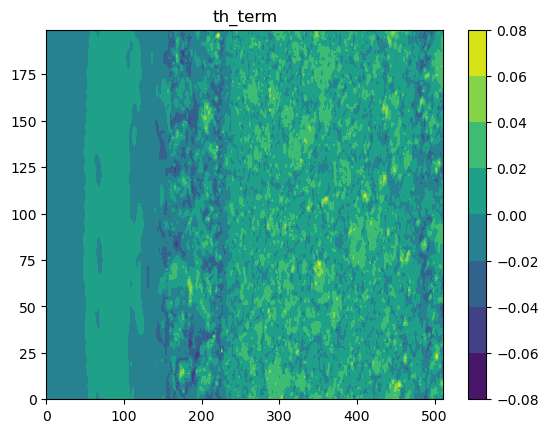

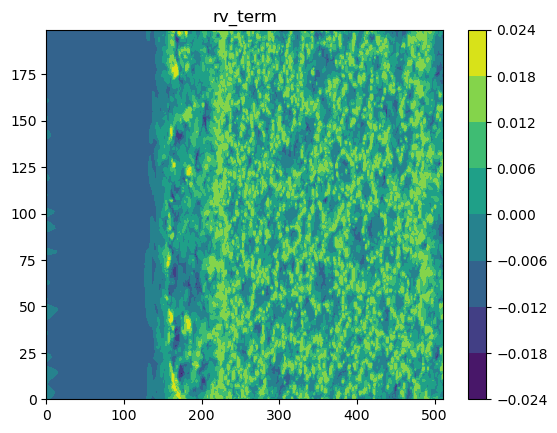

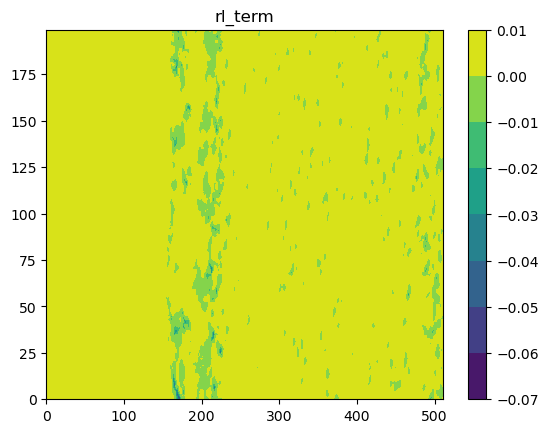

In [136]:
# #PLOTTING CONTRIBUTIONS FROM EACH TERM

# t=100
# approximation=True
# # approximation=False
# in_file=GetOutputName(approximation)
# #READING FINAL OUTPUT
# with h5py.File(in_file, 'a') as f:
#     # Access the existing dataset 'MSE'
#     th_term = f['th_term'][t]
#     rv_term = f['rv_term'][t]
#     rl_term = f['rl_term'][t]

# one=th_term
# two=rv_term
# three=rl_term

# z_lev=10
# plt.contourf(one[z_lev])
# plt.colorbar()
# plt.title(f"th_term")
# plt.show()
# plt.contourf(two[z_lev])
# plt.colorbar()
# plt.title(f"rv_term")
# plt.show()
# plt.contourf(thraee[z_lev])
# plt.colorbar()
# plt.title(f"rl_term")
# plt.show()

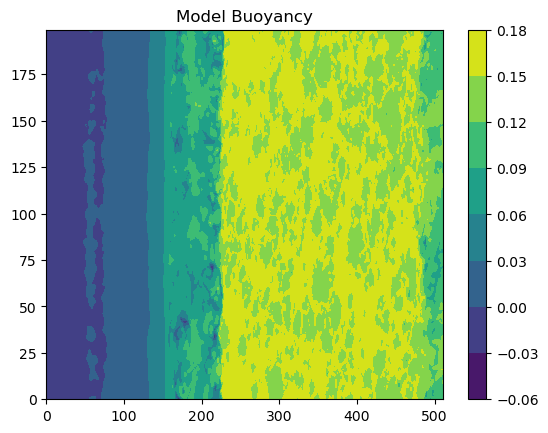

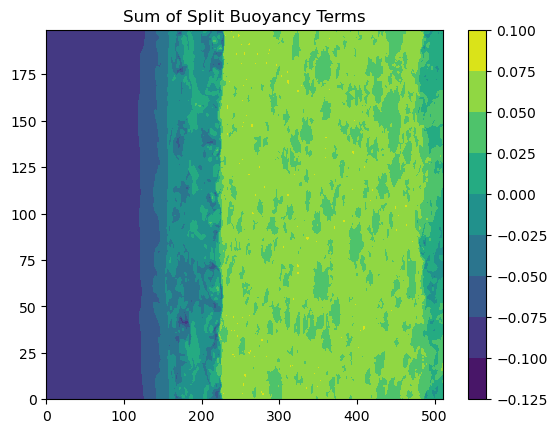

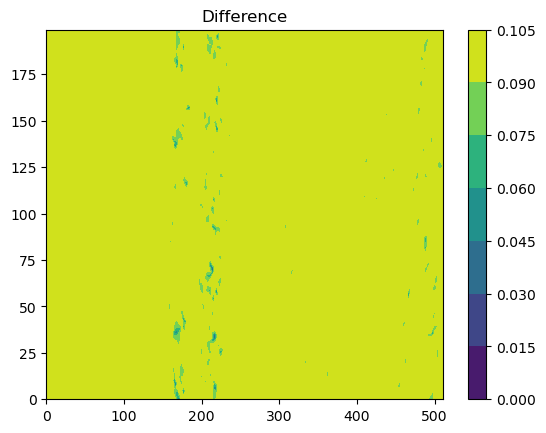

In [137]:
# #TESTING BUOYANCY VS (SUM OF 3 BUOYANCY TERMS)
# t=100
# # approximation=True
# approximation=False
# in_file=GetOutputName(approximation)
# #READING FINAL OUTPUT
# with h5py.File(in_file, 'a') as f:
#     # Access the existing dataset 'MSE'
#     th_term = f['th_term'][t]
#     rv_term = f['rv_term'][t]
#     rl_term = f['rl_term'][t]

# buoyancy1=data.isel(time=t)['buoyancy'].data
# buoyancy2 = th_term + rv_term + rl_term

# one=buoyancy1
# two=buoyancy2
# diff=one-two

# z_lev=5
# plt.contourf(one[z_lev])
# plt.colorbar()
# plt.title('Model Buoyancy')
# plt.show()
# plt.contourf(two[z_lev])
# plt.colorbar()
# plt.title('Sum of Split Buoyancy Terms')
# plt.show()
# plt.contourf(diff[z_lev])
# plt.colorbar()
# plt.title('Difference')
# plt.show()